teacher-distilled student ready | best_rounds = 330
[saved] 06_gate_alpha.csv
[saved] 06_gate_beta_devices.csv
device1 DeLong p = 0.251 (AUC indistinguishable if > 0.05)
refinement CIs overlap: teacher[0.0032,0.0067] miscal[0.0031,0.0065]
reliability(teacher)-reliability(miscal) = -0.00722 CI[-0.00889,-0.00544]
[saved] 06_gate_beta_isoauc.csv
[saved] 06_gate_gamma.csv
[saved] 06_gate_beta_reliability.png  &  06_gate_beta_reliability.pdf


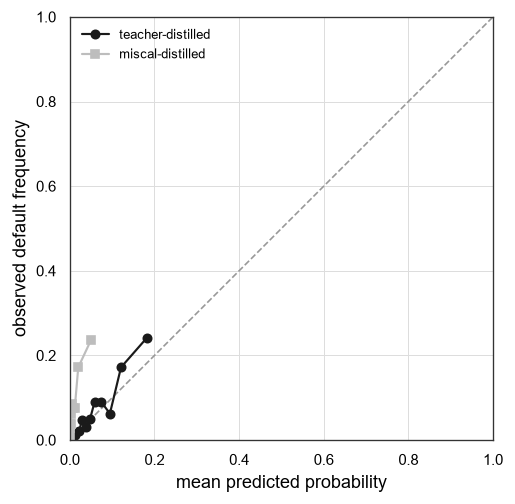

[saved] 06_gate_continuous_vs_integer.csv


,block,variant,integer,reliability,ECE
0,alpha,teacher,False,0.0009,0.0219
1,alpha,a1(eps=0.10),False,0.0033,0.0562
2,alpha,a2(eps=0.55),False,0.0030,0.0370
3,alpha,teacher,True,0.0009,0.0215
4,alpha,a1(eps=0.10),True,0.0032,0.0556
5,alpha,a2(eps=0.55),True,0.0033,0.0382
0,gamma,base(hard),False,0.0010,0.0184
1,gamma,post(hard+isotonic),False,0.0008,0.0210
2,gamma,distill(teacher),False,0.0009,0.0219
3,gamma,base(hard),True,0.0010,0.0205


In [1]:
# Notebook 06 — Calibration-Transfer Gates (Track E)

import json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import common as C
import config as CFG
C.set_grayscale_style()

X = pd.read_pickle(C.PROC_DIR / "X_all.pkl")
y = np.load(C.PROC_DIR / "y_all.npy")
SP = pickle.load(open(C.PROC_DIR / "splits.pkl", "rb"))
meta = json.load(open(C.PROC_DIR / "meta.json"))
FEATURES = meta["features"]
TP = np.load(C.PROC_DIR / "teacher_probs.npz"); pT = {k: TP[k] for k in TP.files}

Xtr, ytr = X.iloc[SP["train"]], y[SP["train"]]
Xes, yes = X.iloc[SP["es"]],   y[SP["es"]]
Xev, yev = X.iloc[SP["eval"]], y[SP["eval"]]

# fixed standard binning shared by all gates (structure held constant)
BIN = C.fit_binning(Xtr, pT["train"], FEATURES, n_bins=5, method="standard")
Xtr_b, Xes_b, Xev_b = (C.apply_binning(d, BIN) for d in (Xtr, Xes, Xev))
PDO_REP, GRID_REP = 20, 1

def entropy(p):
    p = np.clip(p, 1e-6, 1 - 1e-6)
    return float(np.mean(-(p*np.log(p) + (1-p)*np.log(1-p))))

def eval_calib(sc, integer=False):
    p = sc.quantized_proba(Xev_b) if integer else sc.predict_proba(Xev_b)
    bm = C.brier_murphy(yev, p, n_bins=10)
    return {"AUC": C.auc(yev, p), "ECE": C.ece(yev, p),
            "reliability": bm["reliability"], "refinement": bm["refinement"],
            "SpiegelZ": C.spiegelhalter_z(yev, p)["z"], "p": p}

def student_from_target(target):
    sc = C.fit_stump_scorecard(Xtr_b, target, Xes_b, yes)
    sc.quantize(pdo=PDO_REP, grid=GRID_REP, base_points=600)
    return sc

# reference: the teacher-distilled student
sc_teacher = student_from_target(pT["train"])
print("teacher-distilled student ready | best_rounds =", sc_teacher._best_rounds)


# ----------------------------------------------------------------------------
# GATE alpha — softness vs content (entropy-matched uninformative targets)
# ----------------------------------------------------------------------------
target_entropy = entropy(pT["train"])
ybar = ytr.mean()

def alpha_target(kind, eps):
    anchor = 0.5 if kind == "a1" else ybar
    return (1 - eps) * ytr + eps * anchor

def match_eps(kind):
    best, beps = 1e9, 0.5
    for eps in np.linspace(0.05, 0.95, 19):
        e = entropy(alpha_target(kind, eps))
        if abs(e - target_entropy) < best:
            best, beps = abs(e - target_entropy), eps
    return float(beps)

rows = []
for integer in [False, True]:
    ref = eval_calib(sc_teacher, integer)
    rows.append({"gate": "alpha", "target": "teacher", "integer": integer,
                 **{k: ref[k] for k in ["AUC","ECE","reliability","refinement","SpiegelZ"]}})
    for kind in ["a1", "a2"]:
        eps = match_eps(kind)
        sc = student_from_target(alpha_target(kind, eps))
        r = eval_calib(sc, integer)
        rows.append({"gate": "alpha", "target": f"{kind}(eps={eps:.2f})",
                     "integer": integer,
                     **{k: r[k] for k in ["AUC","ECE","reliability","refinement","SpiegelZ"]}})
alpha_tbl = pd.DataFrame(rows)
C.save_table(alpha_tbl.round(5), "06_gate_alpha")
alpha_tbl[alpha_tbl.integer == False].round(4)


# ----------------------------------------------------------------------------
# GATE beta — rank-preserving miscalibration (DECISIVE)
#   p_miscal = sigmoid(logit(p^T)/T_mis), T_mis<1 sharpens -> overconfident,
#   rank (order) preserved exactly at the TEACHER-TARGET level.
# ----------------------------------------------------------------------------
T_MIS = 0.5
p_miscal_train = C.sigmoid(C.logit(pT["train"]) / T_MIS)
sc_miscal = student_from_target(p_miscal_train)

# device 1 (gate): DeLong on the two STUDENTS' eval outputs
pA = sc_teacher.predict_proba(Xev_b)     # teacher-distilled student
pB = sc_miscal.predict_proba(Xev_b)      # miscal-distilled student
d1 = C.delong_test(yev, pA, pB)

# device 3 (main): Murphy refinement CI overlap, then reliability comparison
def refinement_of(p): return lambda yy, pp: C.brier_murphy(yy, pp)["refinement"]
ci_ref_A = C.bootstrap_ci(lambda yy, pp: C.brier_murphy(yy, pp)["refinement"], yev, pA, n_boot=CFG.N_BOOT)
ci_ref_B = C.bootstrap_ci(lambda yy, pp: C.brier_murphy(yy, pp)["refinement"], yev, pB, n_boot=CFG.N_BOOT)
ci_rel_diff = C.bootstrap_ci(
    lambda yy, a, b: C.brier_murphy(yy, a)["reliability"] - C.brier_murphy(yy, b)["reliability"],
    yev, pA, pB, n_boot=CFG.N_BOOT)

beta_summary = pd.DataFrame([{
    "device1_AUC_teacherStu": d1["auc1"], "device1_AUC_miscalStu": d1["auc2"],
    "device1_DeLong_p": d1["p_value"],
    "refine_teacher_lo": ci_ref_A["lo"], "refine_teacher_hi": ci_ref_A["hi"],
    "refine_miscal_lo": ci_ref_B["lo"], "refine_miscal_hi": ci_ref_B["hi"],
    "reliability_diff_mean": ci_rel_diff["mean"],
    "reliability_diff_lo": ci_rel_diff["lo"], "reliability_diff_hi": ci_rel_diff["hi"],
}])
C.save_table(beta_summary.round(6), "06_gate_beta_devices")
print(f"device1 DeLong p = {d1['p_value']:.3f} (AUC indistinguishable if > 0.05)")
print(f"refinement CIs overlap: teacher[{ci_ref_A['lo']:.4f},{ci_ref_A['hi']:.4f}] "
      f"miscal[{ci_ref_B['lo']:.4f},{ci_ref_B['hi']:.4f}]")
print(f"reliability(teacher)-reliability(miscal) = {ci_rel_diff['mean']:+.5f} "
      f"CI[{ci_rel_diff['lo']:+.5f},{ci_rel_diff['hi']:+.5f}]")
beta_summary.round(5)


# ----------------------------------------------------------------------------
# GATE beta — device 2 (robustness only): iso-AUC round matching
#   refit both students at a COMMON fixed number of rounds so AUC is matched by
#   the boosting knob, then compare reliability. Agreement with device 3
#   strengthens the verdict; disagreement is attributed to the round-calibration
#   confound and does NOT overturn device 3.
# ----------------------------------------------------------------------------
R = min(sc_teacher._best_rounds, sc_miscal._best_rounds)
scA_iso = C.fit_stump_scorecard(Xtr_b, pT["train"], Xes_b, yes, fixed_rounds=R)
scB_iso = C.fit_stump_scorecard(Xtr_b, p_miscal_train, Xes_b, yes, fixed_rounds=R)
pA_iso = scA_iso.predict_proba(Xev_b); pB_iso = scB_iso.predict_proba(Xev_b)
iso = pd.DataFrame([{
    "fixed_rounds": R,
    "AUC_teacherStu": C.auc(yev, pA_iso), "AUC_miscalStu": C.auc(yev, pB_iso),
    "reliability_teacherStu": C.brier_murphy(yev, pA_iso)["reliability"],
    "reliability_miscalStu": C.brier_murphy(yev, pB_iso)["reliability"],
}])
C.save_table(iso.round(6), "06_gate_beta_isoauc")
iso.round(5)


# ----------------------------------------------------------------------------
# GATE gamma — post-hoc substitutability
#   base: hard-label, no calibration; post: hard-label + isotonic (fit on es);
#   distill: teacher-distilled student.
# ----------------------------------------------------------------------------
from sklearn.isotonic import IsotonicRegression
sc_base = student_from_target(ytr.astype(float))
# isotonic post-hoc calibration fit on es (kept out of eval)
p_base_es = sc_base.predict_proba(Xes_b)
iso_post = IsotonicRegression(out_of_bounds="clip").fit(p_base_es, yes)

rows = []
for integer in [False, True]:
    rb = eval_calib(sc_base, integer)
    rd = eval_calib(sc_teacher, integer)
    p_base_ev = sc_base.quantized_proba(Xev_b) if integer else sc_base.predict_proba(Xev_b)
    p_post_ev = np.clip(iso_post.transform(p_base_ev), 1e-6, 1 - 1e-6)
    bm_post = C.brier_murphy(yev, p_post_ev)
    rows += [
        {"gate": "gamma", "variant": "base(hard)", "integer": integer,
         "ECE": rb["ECE"], "reliability": rb["reliability"], "AUC": rb["AUC"]},
        {"gate": "gamma", "variant": "post(hard+isotonic)", "integer": integer,
         "ECE": C.ece(yev, p_post_ev), "reliability": bm_post["reliability"],
         "AUC": C.auc(yev, p_post_ev)},
        {"gate": "gamma", "variant": "distill(teacher)", "integer": integer,
         "ECE": rd["ECE"], "reliability": rd["reliability"], "AUC": rd["AUC"]},
    ]
gamma_tbl = pd.DataFrame(rows)
C.save_table(gamma_tbl.round(5), "06_gate_gamma")
gamma_tbl[gamma_tbl.integer == False].round(4)


# ----------------------------------------------------------------------------
# Figure: gate-beta reliability diagrams — teacher-distilled vs miscal-distilled
# ----------------------------------------------------------------------------
def rel_pts(y, p, nb=10):
    ids = C._bin_ids(p, nb, "quantile"); xs, ys = [], []
    for b in np.unique(ids):
        m = ids == b; xs.append(p[m].mean()); ys.append(y[m].mean())
    return np.array(xs), np.array(ys)

fig, ax = plt.subplots(figsize=(4.4, 4.4))
ax.plot([0, 1], [0, 1], color="#999999", linestyle="--", linewidth=1.0)
xa, ya = rel_pts(yev, pA); xb, yb = rel_pts(yev, pB)
ax.plot(xa, ya, marker="o", color="#1a1a1a", linewidth=1.3, markersize=5,
        label="teacher-distilled")
ax.plot(xb, yb, marker="s", color="#bdbdbd", linewidth=1.3, markersize=5,
        label="miscal-distilled")
ax.set_xlabel("mean predicted probability")
ax.set_ylabel("observed default frequency")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal"); ax.legend(fontsize=8)
fig.tight_layout()
C.save_fig(fig, "06_gate_beta_reliability")
plt.show()


# ----------------------------------------------------------------------------
# Continuous vs integer summary across gates (quantization interaction)
# ----------------------------------------------------------------------------
gate_ci = (pd.concat([
    alpha_tbl.assign(block="alpha")[["block","target","integer","reliability","ECE"]]
        .rename(columns={"target":"variant"}),
    gamma_tbl.assign(block="gamma")[["block","variant","integer","reliability","ECE"]],
]))
C.save_table(gate_ci.round(5), "06_gate_continuous_vs_integer")
gate_ci.round(4)
